# 🔍 Customer Churn — Exploratory Data Analysis
**Kaggle Playground Series 2026**

### Notebook structure
1. Setup & Load
2. Dataset overview
3. Early cleaning & harmonisation
4. Target variable
5. The internet service divide
6. The phone service divide
7. Internet add-on services (within internet customers only)
8. Binary demographic & account features
9. Contract & payment features
10. Numerical features
11. Feature importance ranking — model-free
12. Key interactions
13. Train vs Test distribution check
14. Encoding decisions & takeaways

---
## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, chi2_contingency, ks_2samp, mannwhitneyu

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
CHURN_PALETTE = {'No': '#4C8BB5', 'Yes': '#E05C5C'}
plt.rcParams['figure.dpi'] = 120

DATA_DIR = "/Users/clairedebadts/kaggle/customer-churn/data/"

train = pd.read_csv(DATA_DIR + "train.csv")
test  = pd.read_csv(DATA_DIR + "test.csv")

print(f"Train : {train.shape[0]:,} rows x {train.shape[1]} cols")
print(f"Test  : {test.shape[0]:,} rows x {test.shape[1]} cols")

Train : 594,194 rows x 21 cols
Test  : 254,655 rows x 20 cols


---
## 2. Dataset Overview

In [2]:
info = pd.DataFrame({
    'dtype'    : train.dtypes,
    'n_unique' : train.nunique(),
    'missing'  : train.isnull().sum(),
    'missing_%': (train.isnull().mean() * 100).round(2),
    'sample'   : train.iloc[0],
})
print(info.to_string())

                    dtype  n_unique  missing  missing_%        sample
id                  int64    594194        0        0.0             0
gender             object         2        0        0.0          Male
SeniorCitizen       int64         2        0        0.0             0
Partner            object         2        0        0.0           Yes
Dependents         object         2        0        0.0           Yes
tenure              int64        72        0        0.0            29
PhoneService       object         2        0        0.0           Yes
MultipleLines      object         3        0        0.0            No
InternetService    object         3        0        0.0           DSL
OnlineSecurity     object         3        0        0.0           Yes
OnlineBackup       object         3        0        0.0            No
DeviceProtection   object         3        0        0.0           Yes
TechSupport        object         3        0        0.0           Yes
StreamingTV        o

---
## 3. Early Cleaning & Harmonisation

Before any analysis:
- `SeniorCitizen` 0/1 → 'No'/'Yes' (consistent with all other binary columns)
- `PaymentMethod` → split into `payment_type` (Automatic/Manual) and `payment_method` (actual method)

Applied to both train and test.

In [3]:
def harmonise(df):
    df = df.copy()

    # SeniorCitizen: 0/1 -> No/Yes
    df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

    # PaymentMethod -> payment_type + payment_method
    df['payment_type'] = df['PaymentMethod'].apply(
        lambda x: 'Automatic' if 'automatic' in x.lower() else 'Manual'
    )
    df['payment_method'] = (
        df['PaymentMethod']
        .str.replace(r'\s*\(automatic\)', '', regex=True)
        .str.strip()
    )

    return df

train = harmonise(train)
test  = harmonise(test)

print("payment_type unique  :", train['payment_type'].unique().tolist())
print("payment_method unique:", train['payment_method'].unique().tolist())
print("SeniorCitizen unique :", train['SeniorCitizen'].unique().tolist())

payment_type unique  : ['Manual', 'Automatic']
payment_method unique: ['Mailed check', 'Credit card', 'Electronic check', 'Bank transfer']
SeniorCitizen unique : ['No', 'Yes']


In [4]:
# ── Full column map post-harmonisation ────────────────────────────────────
TARGET   = 'Churn'

BINARY_COLS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'PaperlessBilling'
]
INTERNET_ADDON_COLS = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
ACCOUNT_COLS = ['Contract', 'payment_type', 'payment_method']
NUMERICAL    = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Helper: churn rate
def churn_rate(series):
    return (series == 'Yes').mean() * 100

# Helper: summary table per feature
def churn_table(df, col):
    overall = churn_rate(df[TARGET])
    tbl = (
        df.groupby(col)
        .agg(
            count      = (TARGET, 'count'),
            churn_pct  = (TARGET, churn_rate),
        )
        .reset_index()
    )
    tbl['pct_of_customers'] = (tbl['count'] / tbl['count'].sum() * 100).round(1)
    tbl['lift_vs_avg']      = (tbl['churn_pct'] - overall).round(2)
    tbl['churn_pct']        = tbl['churn_pct'].round(2)
    return tbl.sort_values('churn_pct', ascending=False).reset_index(drop=True)

AVG_CHURN = churn_rate(train[TARGET])
print(f"Overall churn rate: {AVG_CHURN:.2f}%")

Overall churn rate: 22.52%


---
## 4. Target Variable

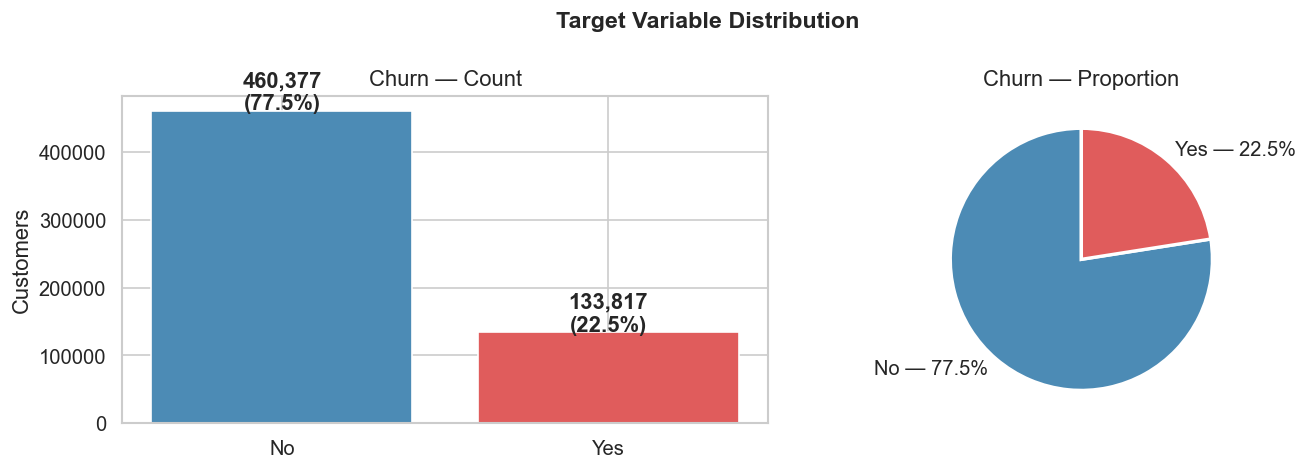

Overall churn rate : 22.52%
Imbalance ratio    : 3.44:1

Implication for modelling:
  XGBoost  -> scale_pos_weight = 3.4
  LightGBM -> is_unbalance=True or class_weight
  Metric   -> ROC-AUC (robust to imbalance, matches competition)


In [5]:
counts = train[TARGET].value_counts()
props  = train[TARGET].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count
bars = axes[0].bar(
    counts.index, counts.values,
    color=[CHURN_PALETTE[k] for k in counts.index],
    edgecolor='white'
)
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2000,
        f"{val:,}\n({val/counts.sum()*100:.1f}%)",
        ha='center', fontweight='bold'
    )
axes[0].set_title('Churn — Count')
axes[0].set_ylabel('Customers')

# Pie
axes[1].pie(
    props.values,
    labels=[f"{k} — {v:.1f}%" for k, v in props.items()],
    colors=[CHURN_PALETTE[k] for k in props.index],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('Churn — Proportion')

fig.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Overall churn rate : {AVG_CHURN:.2f}%")
print(f"Imbalance ratio    : {counts['No']/counts['Yes']:.2f}:1")
print()
print("Implication for modelling:")
print(f"  XGBoost  -> scale_pos_weight = {counts['No']/counts['Yes']:.1f}")
print(f"  LightGBM -> is_unbalance=True or class_weight")
print(f"  Metric   -> ROC-AUC (robust to imbalance, matches competition)")

---
## 5. The Internet Service Divide

This is the most important structural split in the dataset.

Six add-on columns each carry 3 values: `Yes`, `No`, `No internet service`.  
Before analysing those add-ons, we need to understand whether **No internet** customers are a fundamentally different population.

In [10]:
print("=== Churn table — InternetService ===")
print(churn_table(train, 'InternetService').to_string(index=False))

=== Churn table — InternetService ===
InternetService  count  churn_pct  pct_of_customers  lift_vs_avg
    Fiber optic 272386      41.54              45.8        19.02
            DSL 181081      10.31              30.5       -12.21
             No 140727       1.43              23.7       -21.09


In [11]:
# ── Full profile by internet service group ─────────────────────────────────
profile = train.groupby('InternetService').agg(
    n_customers          = ('id', 'count'),
    churn_rate_pct       = (TARGET, churn_rate),
    avg_tenure_months    = ('tenure', 'mean'),
    avg_monthly_charges  = ('MonthlyCharges', 'mean'),
    avg_total_charges    = ('TotalCharges', 'mean'),
    pct_senior           = ('SeniorCitizen', lambda x: (x == 'Yes').mean() * 100),
    pct_has_partner      = ('Partner', lambda x: (x == 'Yes').mean() * 100),
    pct_has_dependents   = ('Dependents', lambda x: (x == 'Yes').mean() * 100),
    pct_monthly_contract = ('Contract', lambda x: (x == 'Month-to-month').mean() * 100),
    pct_paperless        = ('PaperlessBilling', lambda x: (x == 'Yes').mean() * 100),
    pct_auto_payment     = ('payment_type', lambda x: (x == 'Automatic').mean() * 100),
).round(1)

print("=== Customer profile by InternetService ===")
print(profile.T.to_string())

=== Customer profile by InternetService ===
InternetService            DSL  Fiber optic        No
n_customers           181081.0     272386.0  140727.0
churn_rate_pct            10.3         41.5       1.4
avg_tenure_months         39.1         32.6      41.0
avg_monthly_charges       61.8         91.8      20.9
avg_total_charges       2706.3       3188.5     878.2
pct_senior                 4.7         21.3       1.0
pct_has_partner           54.1         47.2      59.0
pct_has_dependents        34.6         17.2      50.0
pct_monthly_contract      42.9         71.2      19.4
pct_paperless             56.1         86.1      20.9
pct_auto_payment          54.7         33.1      46.8


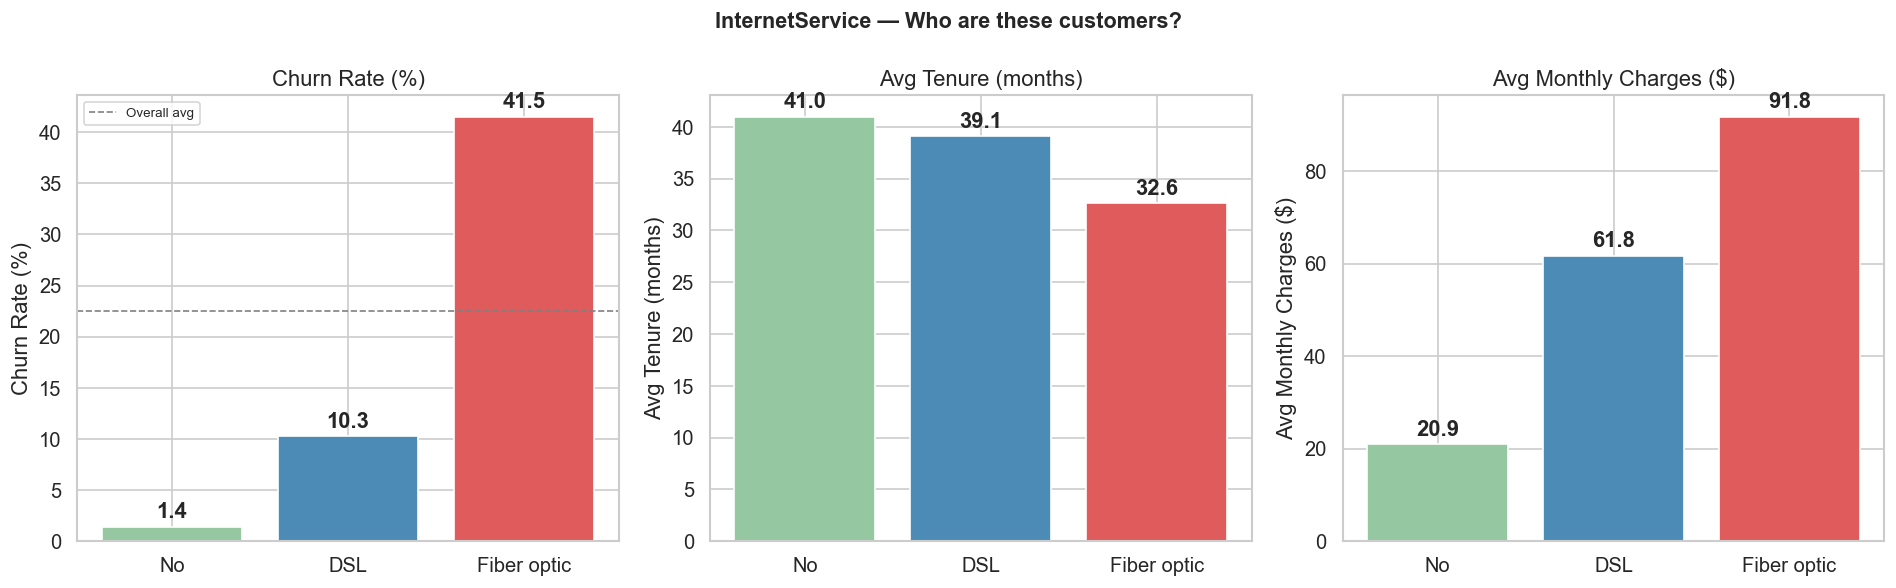

In [12]:
# ── Visual: 3 key metrics by internet group ────────────────────────────────
internet_order  = ['No', 'DSL', 'Fiber optic']
internet_colors = ['#95C8A0', '#4C8BB5', '#E05C5C']

metrics = {
    'Churn Rate (%)' : train.groupby('InternetService')[TARGET].apply(churn_rate),
    'Avg Tenure (months)' : train.groupby('InternetService')['tenure'].mean(),
    'Avg Monthly Charges ($)': train.groupby('InternetService')['MonthlyCharges'].mean(),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (title, values) in zip(axes, metrics.items()):
    vals = values.reindex(internet_order)
    bars = ax.bar(internet_order, vals.values, color=internet_colors, edgecolor='white')
    for bar, val in zip(bars, vals.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + vals.max() * 0.02,
            f'{val:.1f}', ha='center', fontweight='bold'
        )
    ax.set_title(title)
    ax.set_ylabel(title)
    if 'Churn' in title:
        ax.axhline(AVG_CHURN, color='grey', linestyle='--', linewidth=1, label='Overall avg')
        ax.legend(fontsize=8)

fig.suptitle('InternetService — Who are these customers?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Key observations:
  • No internet customers: lowest churn, longest tenure, cheapest bills → loyal, stable
  • Fiber optic: highest churn by far despite (or because of) highest charges
  • DSL: moderate churn, sits between the two
  → InternetService is likely the single most important feature
  → 'No internet service' in add-on columns is a MEANINGFUL signal, not missing data

---
## 6. The Phone Service Divide

`MultipleLines` has 3 values: `Yes`, `No`, `No phone service`.  
Same question — is `No phone service` a distinct customer type?

In [13]:
print("=== Churn table — PhoneService ===")
print(churn_table(train, 'PhoneService').to_string(index=False))
print()
print("=== Churn table — MultipleLines ===")
print(churn_table(train, 'MultipleLines').to_string(index=False))

=== Churn table — PhoneService ===
PhoneService  count  churn_pct  pct_of_customers  lift_vs_avg
         Yes 557893      22.89              93.9         0.37
          No  36301      16.81               6.1        -5.71

=== Churn table — MultipleLines ===
   MultipleLines  count  churn_pct  pct_of_customers  lift_vs_avg
             Yes 274509      27.70              46.2         5.18
              No 283384      18.23              47.7        -4.29
No phone service  36301      16.81               6.1        -5.71


In [15]:
# ── Profile: No phone service vs phone customers ───────────────────────────
phone_profile = train.groupby('MultipleLines').agg(
    n_customers         = ('id', 'count'),
    churn_rate_pct      = (TARGET, churn_rate),
    avg_tenure          = ('tenure', 'mean'),
    avg_monthly         = ('MonthlyCharges', 'mean'),
    pct_fiber           = ('InternetService', lambda x: (x == 'Fiber optic').mean() * 100),
    pct_monthly_contract= ('Contract', lambda x: (x == 'Month-to-month').mean() * 100),
).round(1)

print("=== Profile by MultipleLines ===")
print(phone_profile.T.to_string())


=== Profile by MultipleLines ===
MultipleLines               No  No phone service       Yes
n_customers           283384.0           36301.0  274509.0
churn_rate_pct            18.2              16.8      27.7
avg_tenure                30.1              33.6      43.7
avg_monthly               51.0              42.3      84.3
pct_fiber                 30.9               0.0      67.3
pct_monthly_contract      51.3              53.4      48.9


Key observations:
  • 'No phone service' customers: distinct group — lower charges, different profile
  • MultipleLines Yes vs No: similar churn rates — phone add-on is weak signal
  → Keep 3-way split for MultipleLines, do not collapse

---
## 7. Internet Add-On Services

Analysed **within internet customers only** (DSL + Fiber optic), since `No internet service` is already captured by `InternetService`.

Question: does having/not having each add-on affect churn?

In [16]:
internet_customers = train[train['InternetService'] != 'No'].copy()
print(f"Internet customers: {len(internet_customers):,} ({len(internet_customers)/len(train)*100:.1f}% of train)")
print(f"Churn rate within internet customers: {churn_rate(internet_customers[TARGET]):.2f}%")

Internet customers: 453,467 (76.3% of train)
Churn rate within internet customers: 29.07%


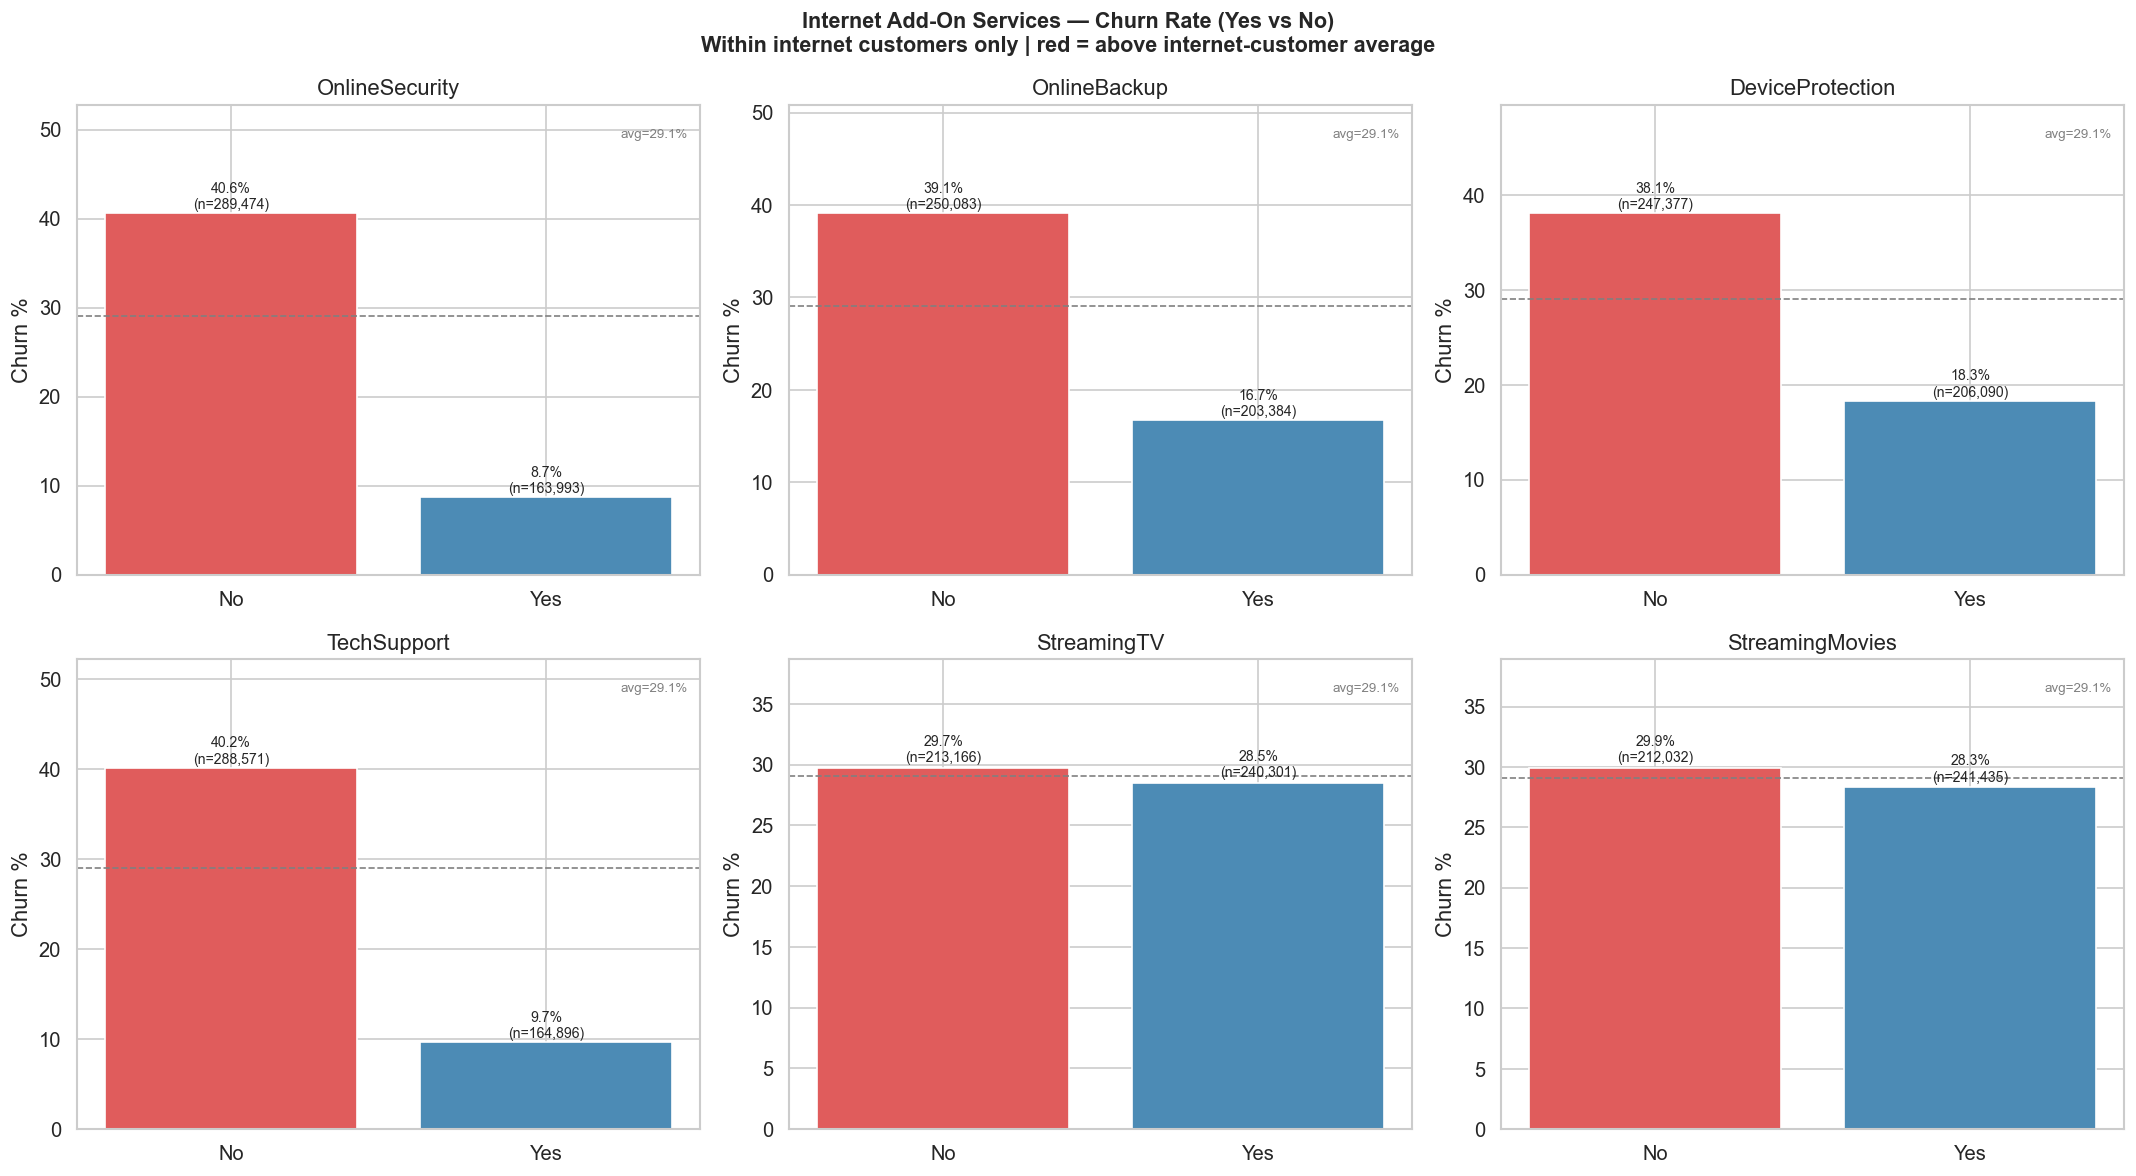

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

internet_avg = churn_rate(internet_customers[TARGET])

for i, col in enumerate(INTERNET_ADDON_COLS):
    ax = axes[i]

    # Only Yes / No within internet customers
    sub = internet_customers[internet_customers[col].isin(['Yes', 'No'])]
    tbl = churn_table(sub, col)

    colors = ['#E05C5C' if v > internet_avg else '#4C8BB5'
              for v in tbl['churn_pct']]
    bars = ax.bar(
        tbl[col].astype(str), tbl['churn_pct'],
        color=colors, edgecolor='white'
    )
    for bar, row in zip(bars, tbl.itertuples()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{row.churn_pct:.1f}%\n(n={row.count:,})",
            ha='center', fontsize=8.5
        )
    ax.axhline(internet_avg, color='grey', linestyle='--', linewidth=1)
    ax.set_title(col)
    ax.set_ylabel('Churn %')
    ax.set_ylim(0, tbl['churn_pct'].max() * 1.3)
    ax.text(0.98, 0.95, f'avg={internet_avg:.1f}%', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='grey')

fig.suptitle(
    'Internet Add-On Services — Churn Rate (Yes vs No)\nWithin internet customers only | red = above internet-customer average',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [19]:
# ── Summary: lift of each add-on ───────────────────────────────────────────
print("Churn rate lift — having vs not having each add-on (within internet customers):\n")
print(f"{'Feature':<22} {'Yes churn%':>12} {'No churn%':>12} {'Lift (No-Yes)':>15}")
print('-' * 65)
for col in INTERNET_ADDON_COLS:
    sub = internet_customers[internet_customers[col].isin(['Yes','No'])]
    yes_rate = churn_rate(sub[sub[col]=='Yes'][TARGET])
    no_rate  = churn_rate(sub[sub[col]=='No'][TARGET])
    lift     = no_rate - yes_rate
    print(f"{col:<22} {yes_rate:>11.1f}% {no_rate:>11.1f}% {lift:>+14.1f}pp")

print()

Churn rate lift — having vs not having each add-on (within internet customers):

Feature                  Yes churn%    No churn%   Lift (No-Yes)
-----------------------------------------------------------------
OnlineSecurity                 8.7%        40.6%          +31.9pp
OnlineBackup                  16.7%        39.1%          +22.4pp
DeviceProtection              18.3%        38.1%          +19.8pp
TechSupport                    9.6%        40.2%          +30.5pp
StreamingTV                   28.5%        29.7%           +1.3pp
StreamingMovies               28.3%        29.9%           +1.6pp



Having the add-on for online security, online backup and techsupport helps retain the customers. The streaming add-on has the minimal effect on the churn.

---
## 8. Binary Demographic & Account Features

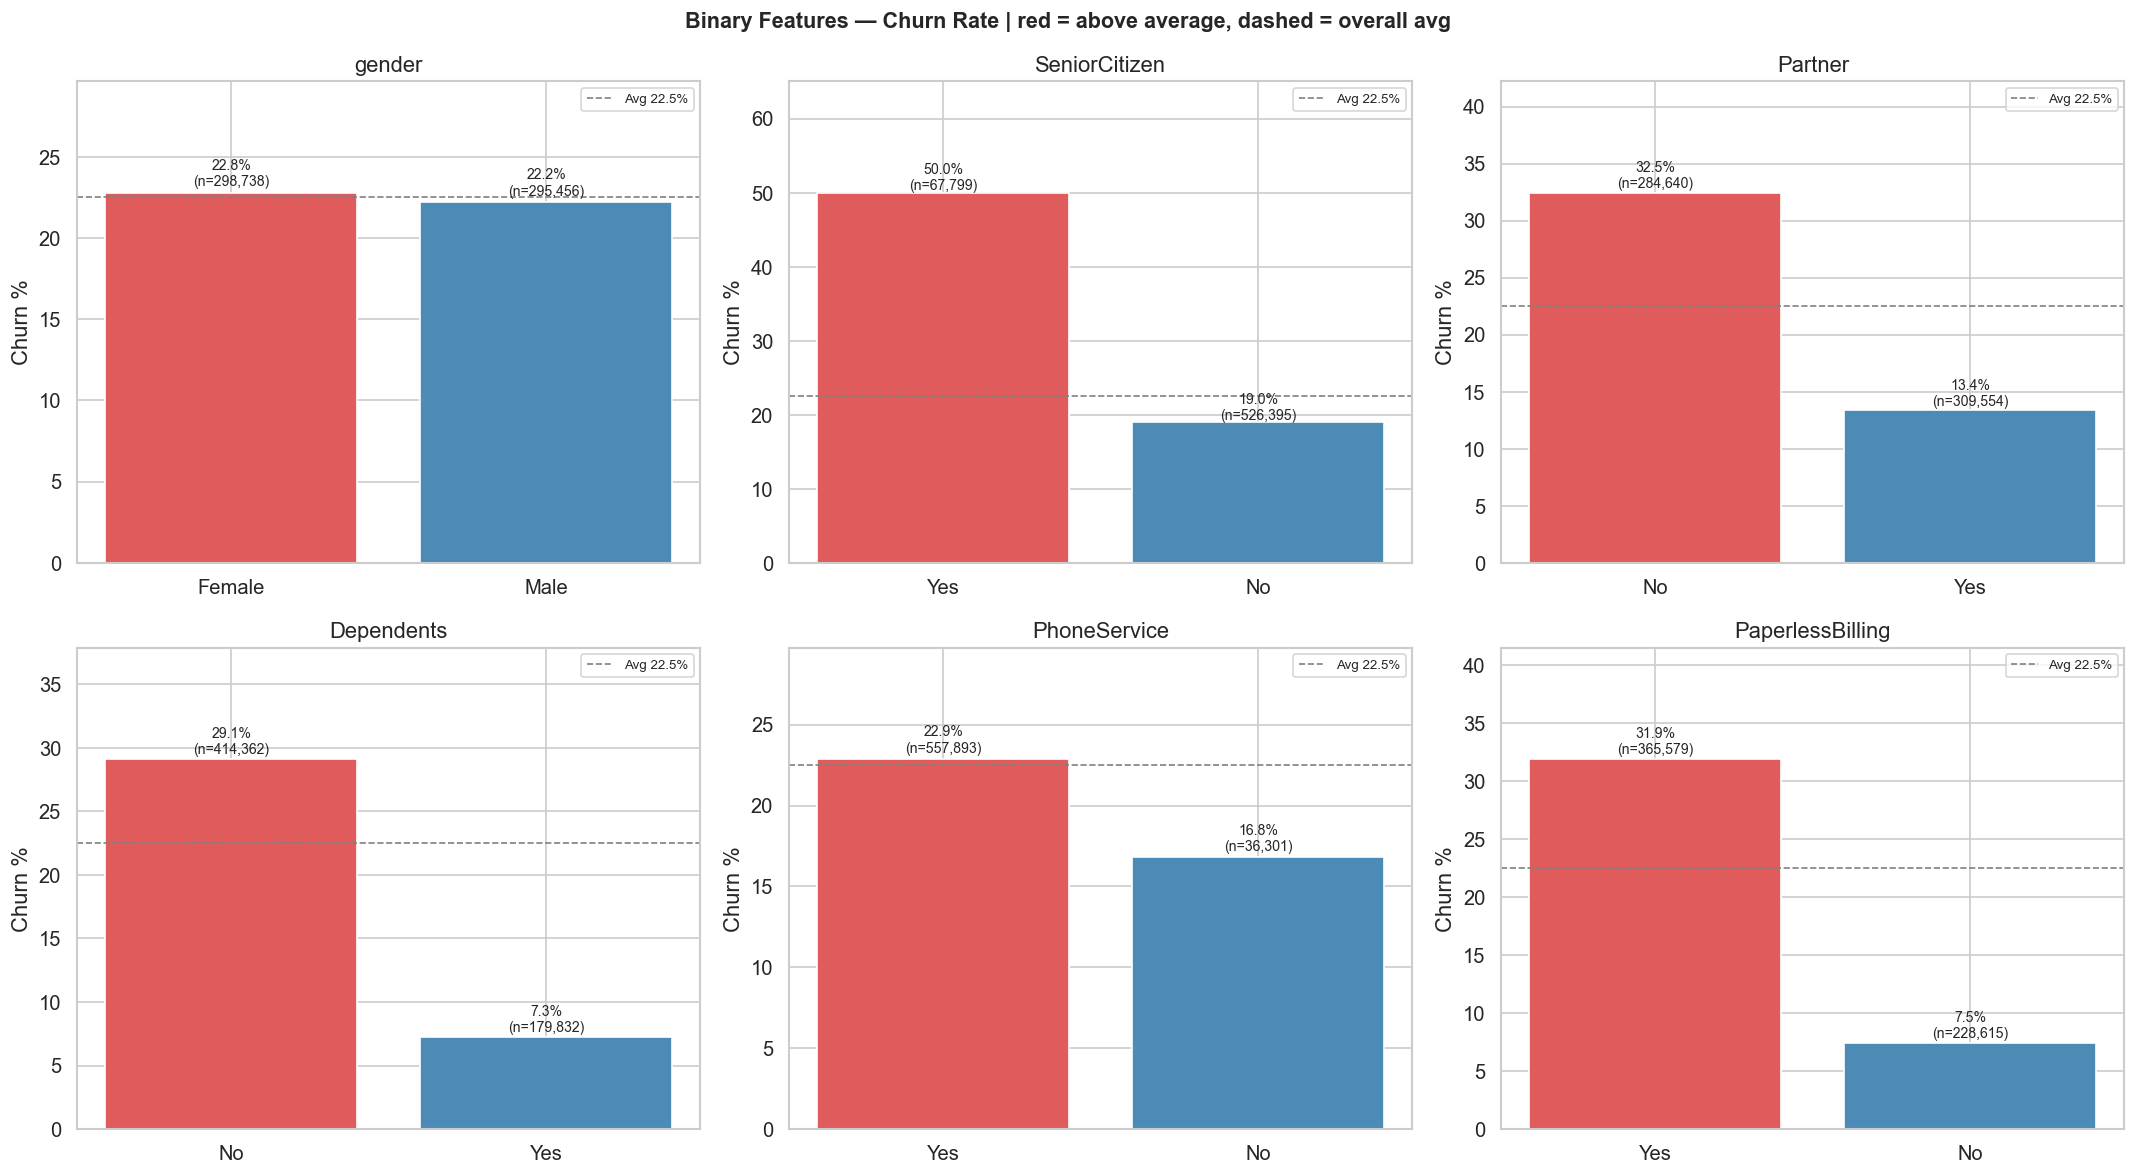


Summary tables:

── gender ──
gender  count  churn_pct  pct_of_customers  lift_vs_avg
Female 298738      22.80              50.3         0.28
  Male 295456      22.23              49.7        -0.29

── SeniorCitizen ──
SeniorCitizen  count  churn_pct  pct_of_customers  lift_vs_avg
          Yes  67799      50.03              11.4        27.51
           No 526395      18.98              88.6        -3.54

── Partner ──
Partner  count  churn_pct  pct_of_customers  lift_vs_avg
     No 284640      32.46              47.9         9.94
    Yes 309554      13.38              52.1        -9.14

── Dependents ──
Dependents  count  churn_pct  pct_of_customers  lift_vs_avg
        No 414362      29.14              69.7         6.61
       Yes 179832       7.28              30.3       -15.24

── PhoneService ──
PhoneService  count  churn_pct  pct_of_customers  lift_vs_avg
         Yes 557893      22.89              93.9         0.37
          No  36301      16.81               6.1        -5.71



In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(BINARY_COLS):
    ax = axes[i]
    tbl = churn_table(train, col)

    colors = ['#E05C5C' if v > AVG_CHURN else '#4C8BB5' for v in tbl['churn_pct']]
    bars = ax.bar(
        tbl[col].astype(str), tbl['churn_pct'],
        color=colors, edgecolor='white'
    )
    for bar, row in zip(bars, tbl.itertuples()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            f"{row.churn_pct:.1f}%\n(n={row.count:,})",
            ha='center', fontsize=8.5
        )
    ax.axhline(AVG_CHURN, color='grey', linestyle='--', linewidth=1, label=f'Avg {AVG_CHURN:.1f}%')
    ax.set_title(col)
    ax.set_ylabel('Churn %')
    ax.set_ylim(0, tbl['churn_pct'].max() * 1.3)
    ax.legend(fontsize=8)

fig.suptitle(
    'Binary Features — Churn Rate | red = above average, dashed = overall avg',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("\nSummary tables:\n")
for col in BINARY_COLS:
    print(f"── {col} ──")
    print(churn_table(train, col).to_string(index=False))
    print()

---
## 9. Contract & Payment Features

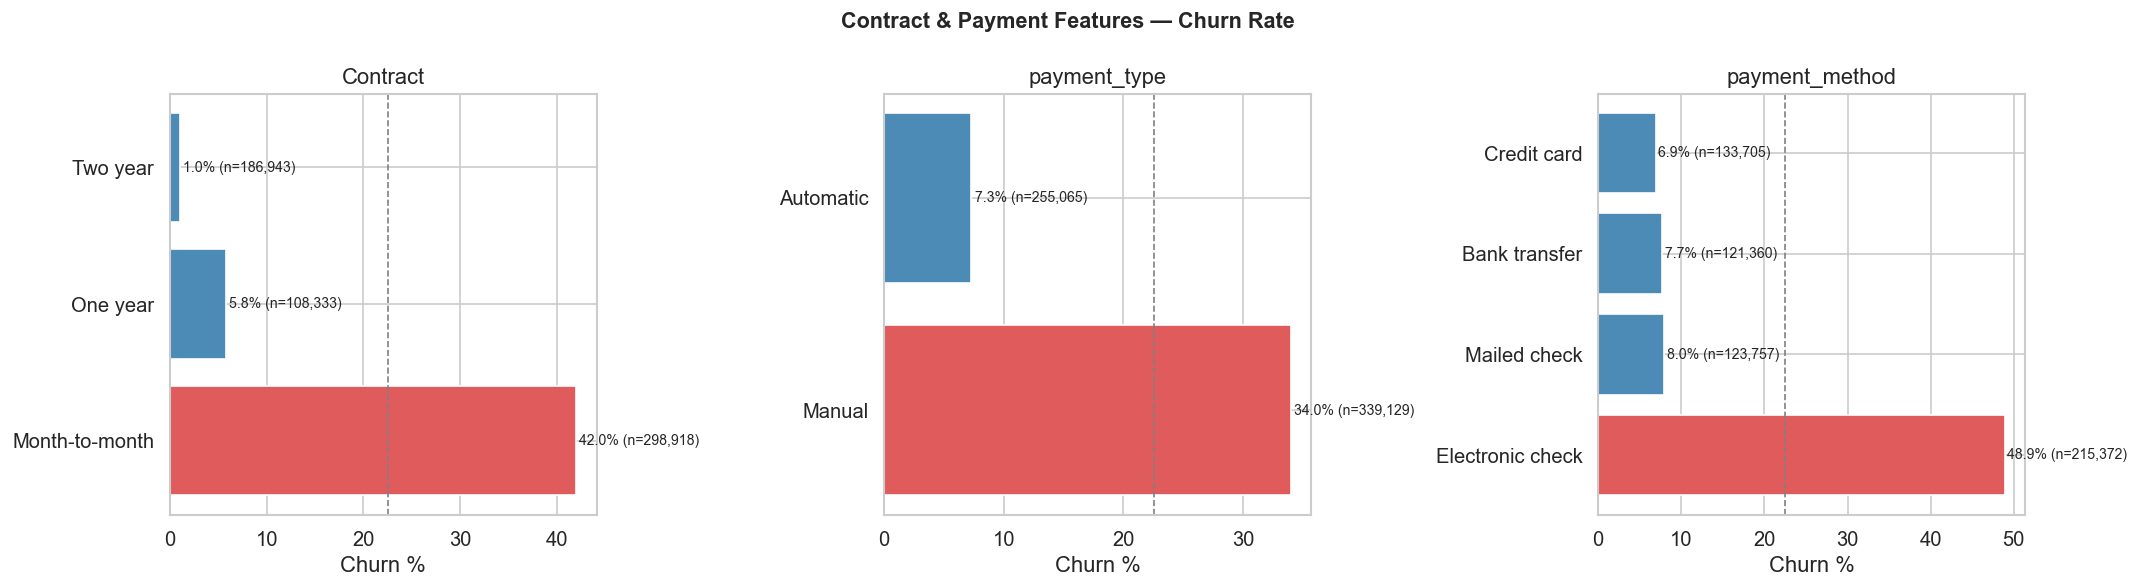


Summary tables:

── Contract ──
      Contract  count  churn_pct  pct_of_customers  lift_vs_avg
Month-to-month 298918      42.05              50.3        19.53
      One year 108333       5.76              18.2       -16.76
      Two year 186943       1.00              31.5       -21.52

── payment_type ──
payment_type  count  churn_pct  pct_of_customers  lift_vs_avg
      Manual 339129      33.97              57.1        11.45
   Automatic 255065       7.30              42.9       -15.22

── payment_method ──
  payment_method  count  churn_pct  pct_of_customers  lift_vs_avg
Electronic check 215372      48.91              36.2        26.38
    Mailed check 123757       7.97              20.8       -14.55
   Bank transfer 121360       7.71              20.4       -14.81
     Credit card 133705       6.93              22.5       -15.59



In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ACCOUNT_COLS):
    tbl = churn_table(train, col)

    colors = ['#E05C5C' if v > AVG_CHURN else '#4C8BB5' for v in tbl['churn_pct']]
    bars = ax.barh(
        tbl[col].astype(str), tbl['churn_pct'],
        color=colors, edgecolor='white'
    )
    for bar, row in zip(bars, tbl.itertuples()):
        ax.text(
            row.churn_pct + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{row.churn_pct:.1f}% (n={row.count:,})",
            va='center', fontsize=8.5
        )
    ax.axvline(AVG_CHURN, color='grey', linestyle='--', linewidth=1)
    ax.set_title(col)
    ax.set_xlabel('Churn %')

fig.suptitle('Contract & Payment Features — Churn Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSummary tables:\n")
for col in ACCOUNT_COLS:
    print(f"── {col} ──")
    print(churn_table(train, col).to_string(index=False))
    print()

---
## 10. Numerical Features
**tenure, MonthlyCharges, TotalCharges**

/var/folders/9j/9_hgqf6s3_sdp7nqq00j33980000gn/T/ipykernel_94657/2870096995.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(
/var/folders/9j/9_hgqf6s3_sdp7nqq00j33980000gn/T/ipykernel_94657/2870096995.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(
/var/folders/9j/9_hgqf6s3_sdp7nqq00j33980000gn/T/ipykernel_94657/2870096995.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(


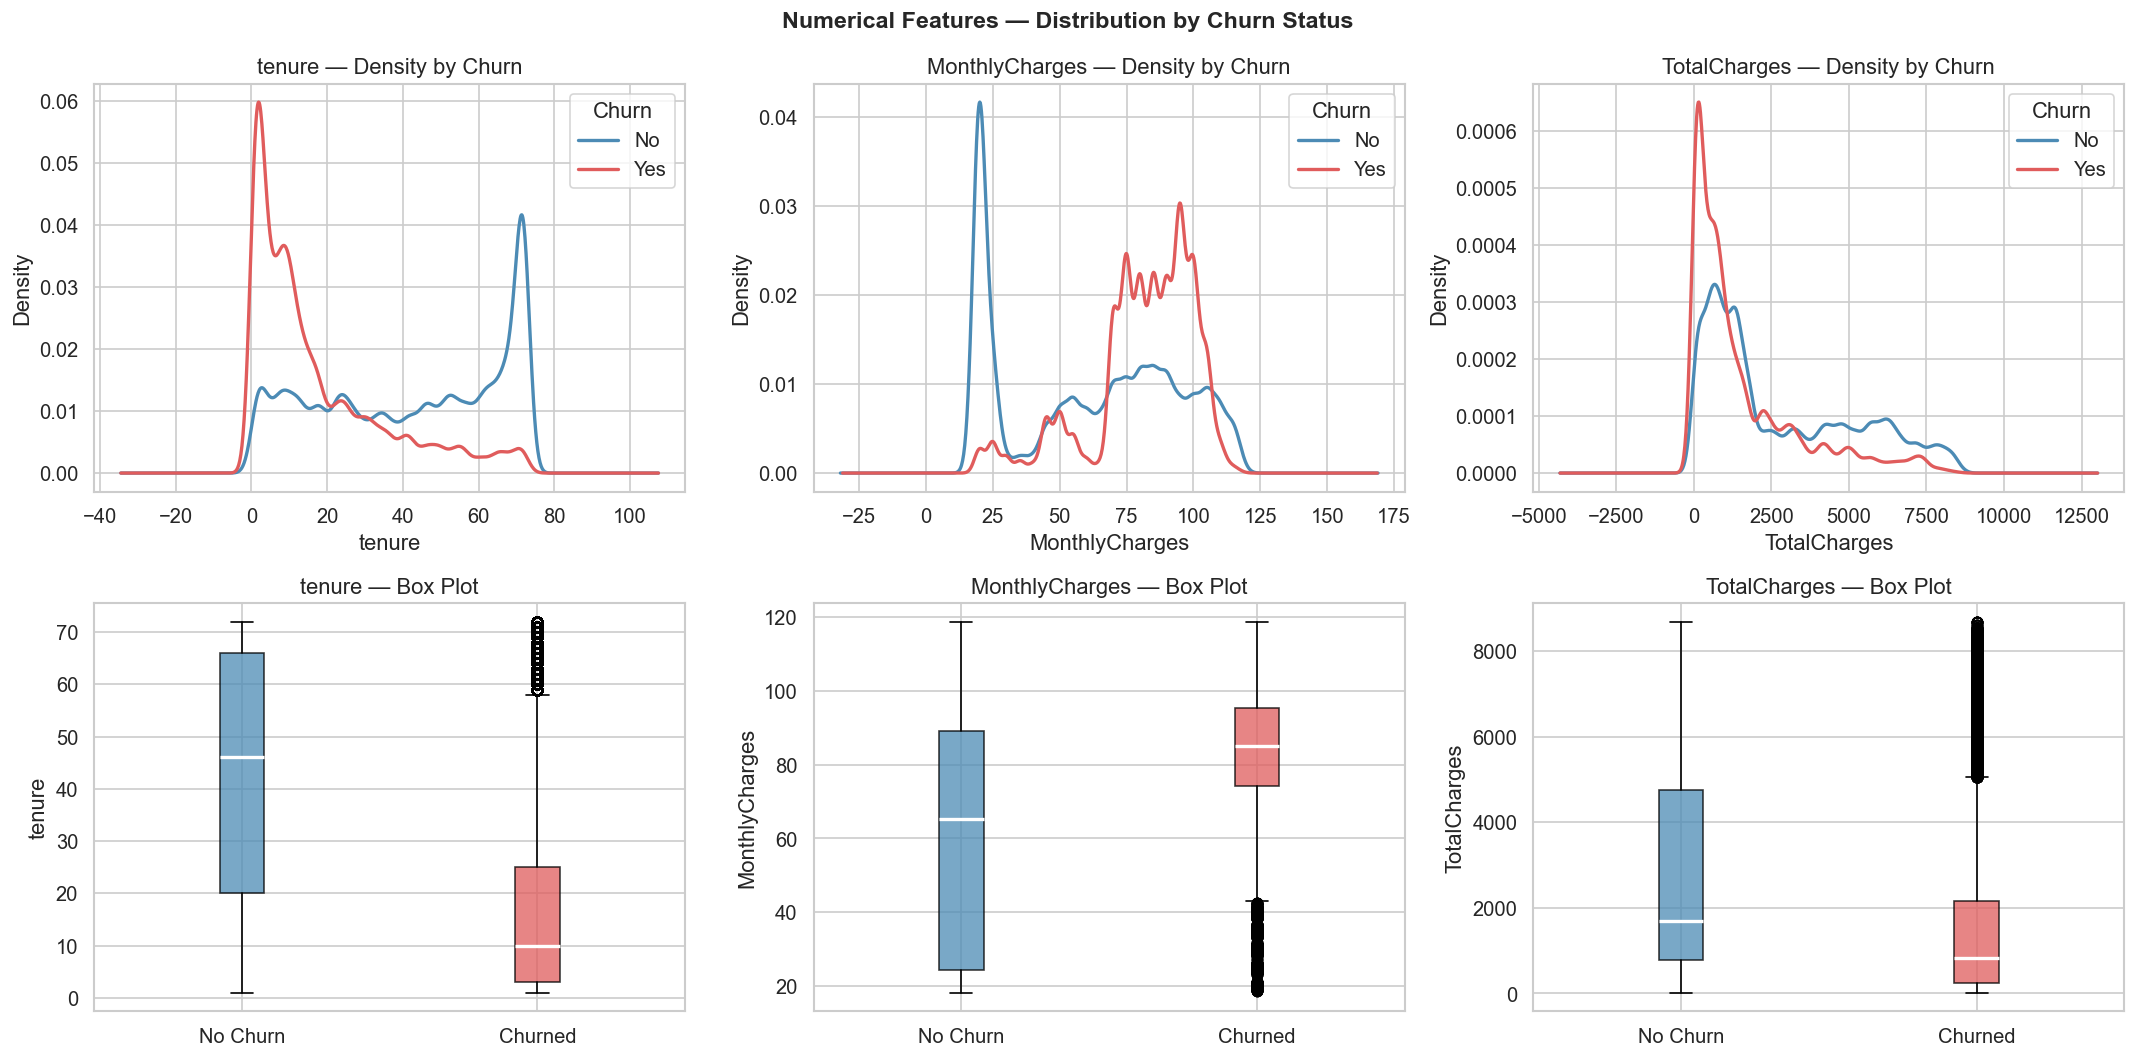

In [22]:
# ── Distributions by churn status ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for i, col in enumerate(NUMERICAL):
    # KDE
    ax_kde = axes[0, i]
    for label, color in CHURN_PALETTE.items():
        train[train[TARGET] == label][col].plot.kde(
            ax=ax_kde, label=label, color=color, linewidth=2
        )
    ax_kde.set_title(f'{col} — Density by Churn')
    ax_kde.set_xlabel(col)
    ax_kde.legend(title='Churn')

    # Boxplot
    ax_box = axes[1, i]
    groups = [train[train[TARGET] == l][col].values for l in ['No', 'Yes']]
    bp = ax_box.boxplot(
        groups, labels=['No Churn', 'Churned'],
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2)
    )
    for patch, color in zip(bp['boxes'], ['#4C8BB5', '#E05C5C']):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax_box.set_title(f'{col} — Box Plot')
    ax_box.set_ylabel(col)

fig.suptitle('Numerical Features — Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# ── Descriptive stats & significance test ────────────────────────────────
print("Descriptive stats and Mann-Whitney U test (non-parametric):\n")
for col in NUMERICAL:
    print(f"── {col} ──")
    tbl = train.groupby(TARGET)[col].agg(['mean', 'median', 'std']).round(2)
    print(tbl.to_string())
    stat, p = mannwhitneyu(
        train[train[TARGET]=='No'][col],
        train[train[TARGET]=='Yes'][col],
        alternative='two-sided'
    )
    print(f"   Mann-Whitney p = {p:.2e}  {'✅ significant' if p < 0.05 else '❌ not significant'}")
    print()

Descriptive stats and Mann-Whitney U test (non-parametric):

── tenure ──
        mean  median    std
Churn                      
No     42.23    46.0  23.99
Yes    17.13    10.0  17.92
   Mann-Whitney p = 0.00e+00  ✅ significant

── MonthlyCharges ──
        mean  median    std
Churn                      
No     61.29   65.40  32.29
Yes    81.60   85.05  19.49
   Mann-Whitney p = 0.00e+00  ✅ significant

── TotalCharges ──
          mean   median      std
Churn                           
No     2771.50  1688.75  2423.05
Yes    1540.98   829.55  1797.64
   Mann-Whitney p = 0.00e+00  ✅ significant



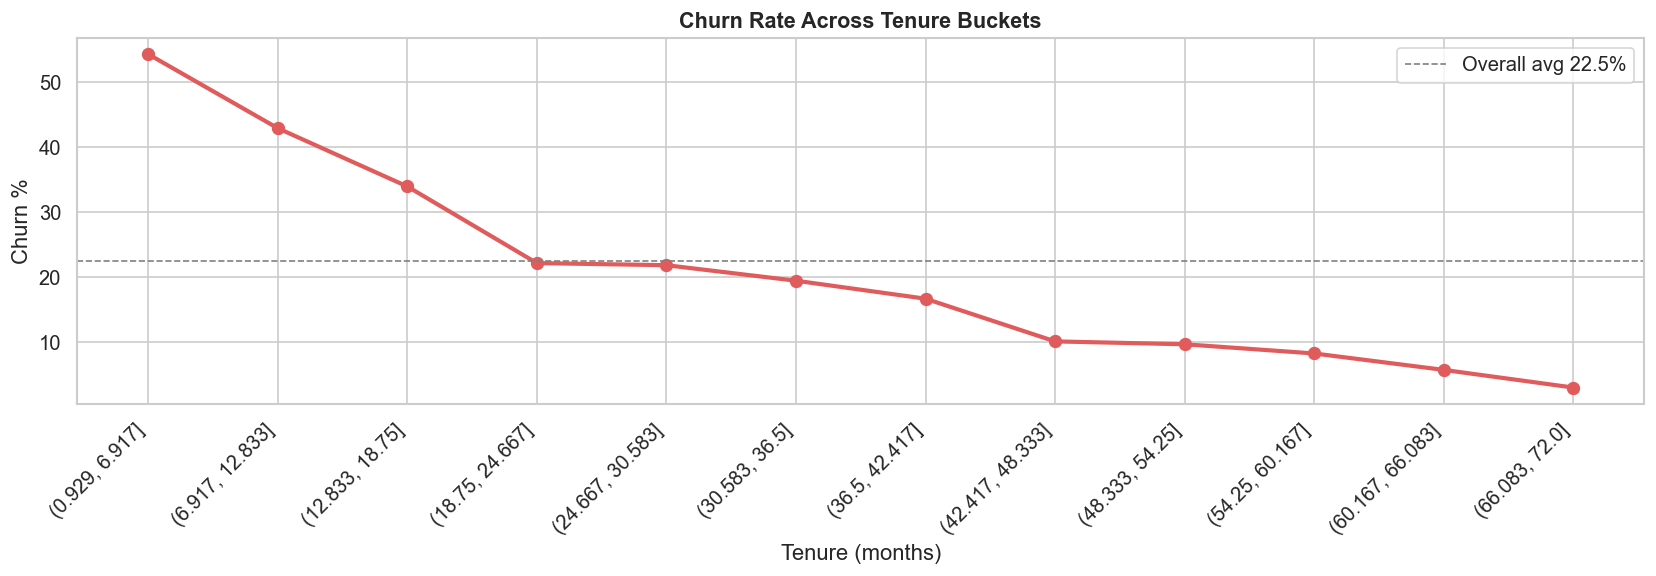

In [24]:
# ── Tenure: churn rate across tenure months ────────────────────────────────
train['tenure_bin'] = pd.cut(train['tenure'], bins=12)
tenure_churn = (
    train.groupby('tenure_bin', observed=True)[TARGET]
    .apply(churn_rate)
    .reset_index()
)
tenure_churn.columns = ['tenure_bin', 'churn_pct']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    range(len(tenure_churn)),
    tenure_churn['churn_pct'],
    marker='o', color='#E05C5C', linewidth=2.5, markersize=7
)
ax.set_xticks(range(len(tenure_churn)))
ax.set_xticklabels(
    [str(b) for b in tenure_churn['tenure_bin']],
    rotation=45, ha='right'
)
ax.axhline(AVG_CHURN, color='grey', linestyle='--', linewidth=1, label=f'Overall avg {AVG_CHURN:.1f}%')
ax.set_title('Churn Rate Across Tenure Buckets', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn %')
ax.set_xlabel('Tenure (months)')
ax.legend()
plt.tight_layout()
plt.show()

train.drop(columns='tenure_bin', inplace=True)

---
## 11. Feature Importance Ranking — Model-Free

- **Cramér's V** for categorical features: measures association strength with Churn (0 = no association, 1 = perfect)
- **Point-biserial correlation** for numerical features

In [25]:
def cramers_v(col_a, col_b):
    """Cramér's V between two categorical series."""
    confusion_matrix = pd.crosstab(col_a, col_b)
    chi2, _, _, _ = chi2_contingency(confusion_matrix)
    n    = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    r_corr = r - (r-1)**2 / (n-1)
    k_corr = k - (k-1)**2 / (n-1)
    return np.sqrt(phi2_corr / min(k_corr-1, r_corr-1))

importance = {}

# Categorical features
all_cat = BINARY_COLS + INTERNET_ADDON_COLS + ['MultipleLines', 'InternetService'] + ACCOUNT_COLS
for col in all_cat:
    importance[col] = {'type': 'categorical', 'score': cramers_v(train[col], train[TARGET])}

# Numerical features
churn_binary = (train[TARGET] == 'Yes').astype(int)
for col in NUMERICAL:
    r, _ = pointbiserialr(train[col], churn_binary)
    importance[col] = {'type': 'numerical', 'score': abs(r)}

# SeniorCitizen
importance['SeniorCitizen'] = {'type': 'categorical', 'score': cramers_v(train['SeniorCitizen'], train[TARGET])}

imp_df = (
    pd.DataFrame(importance).T
    .reset_index()
    .rename(columns={'index': 'feature', 'score': 'importance_score'})
    .sort_values('importance_score', ascending=False)
    .reset_index(drop=True)
)
imp_df['importance_score'] = imp_df['importance_score'].astype(float).round(4)
imp_df['rank'] = range(1, len(imp_df) + 1)

print(imp_df.to_string(index=False))

         feature        type  importance_score  rank
  payment_method categorical            0.4763     1
        Contract categorical            0.4721     2
  OnlineSecurity categorical            0.4267     3
 InternetService categorical            0.4259     4
          tenure   numerical            0.4185     5
     TechSupport categorical            0.4163     6
    OnlineBackup categorical            0.3651     7
DeviceProtection categorical            0.3487     8
    payment_type categorical            0.3159     9
PaperlessBilling categorical            0.2851    10
 StreamingMovies categorical            0.2818    11
     StreamingTV categorical            0.2816    12
  MonthlyCharges   numerical            0.2730    13
      Dependents categorical            0.2404    14
   SeniorCitizen categorical            0.2364    15
         Partner categorical            0.2282    16
    TotalCharges   numerical            0.2184    17
   MultipleLines categorical            0.1152

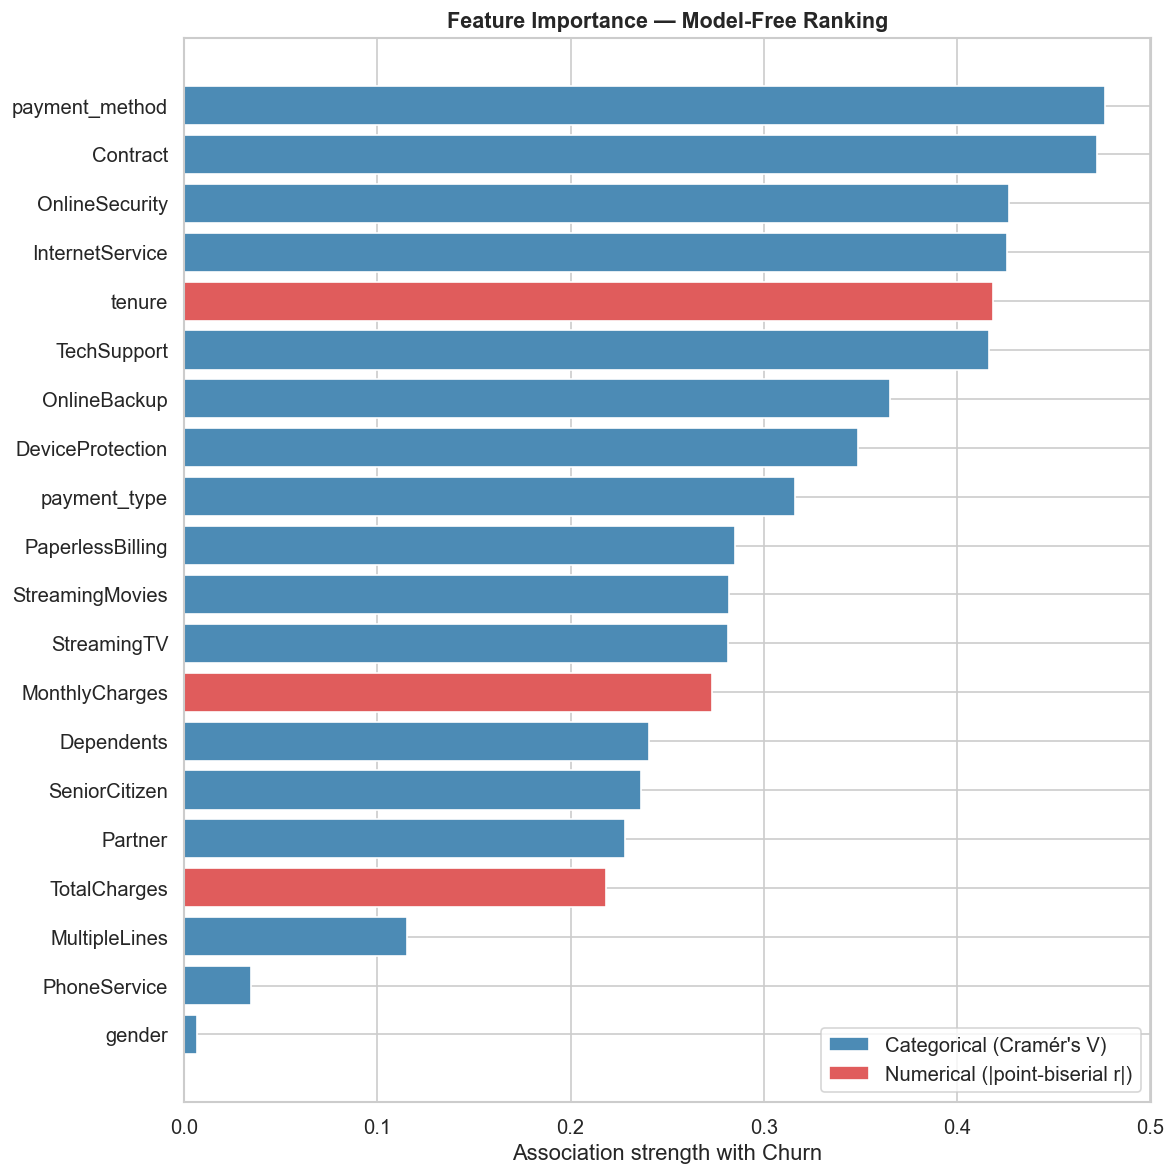

In [26]:
# ── Visual: feature importance ranking ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

colors = ['#4C8BB5' if t == 'categorical' else '#E05C5C'
          for t in imp_df['type']]
ax.barh(
    imp_df['feature'][::-1],
    imp_df['importance_score'][::-1],
    color=colors[::-1],
    edgecolor='white'
)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C8BB5', label="Categorical (Cramér's V)"),
    Patch(facecolor='#E05C5C', label='Numerical (|point-biserial r|)')
]
ax.legend(handles=legend_elements, loc='lower right')
ax.set_xlabel('Association strength with Churn')
ax.set_title('Feature Importance — Model-Free Ranking', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Key Interactions

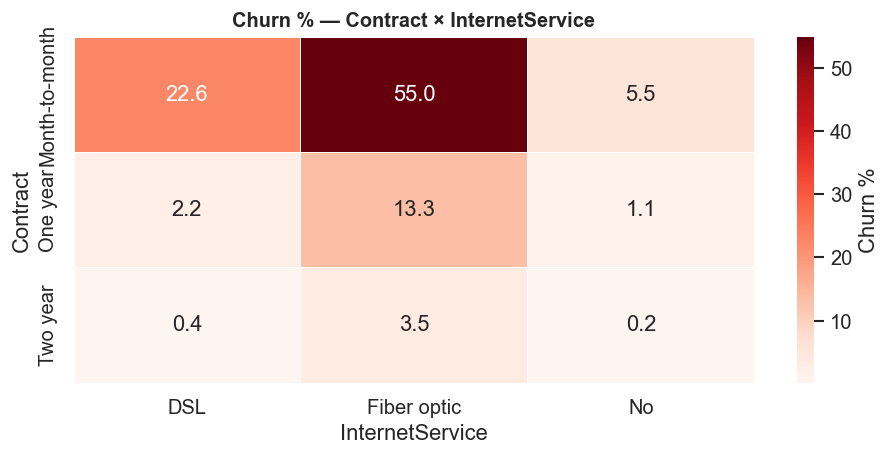

In [27]:
# ── Contract × InternetService ─────────────────────────────────────────────
pivot = (
    train.groupby(['Contract', 'InternetService'])[TARGET]
    .apply(churn_rate)
    .unstack()
    .round(1)
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='Reds',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Churn %'}
)
ax.set_title('Churn % — Contract × InternetService', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

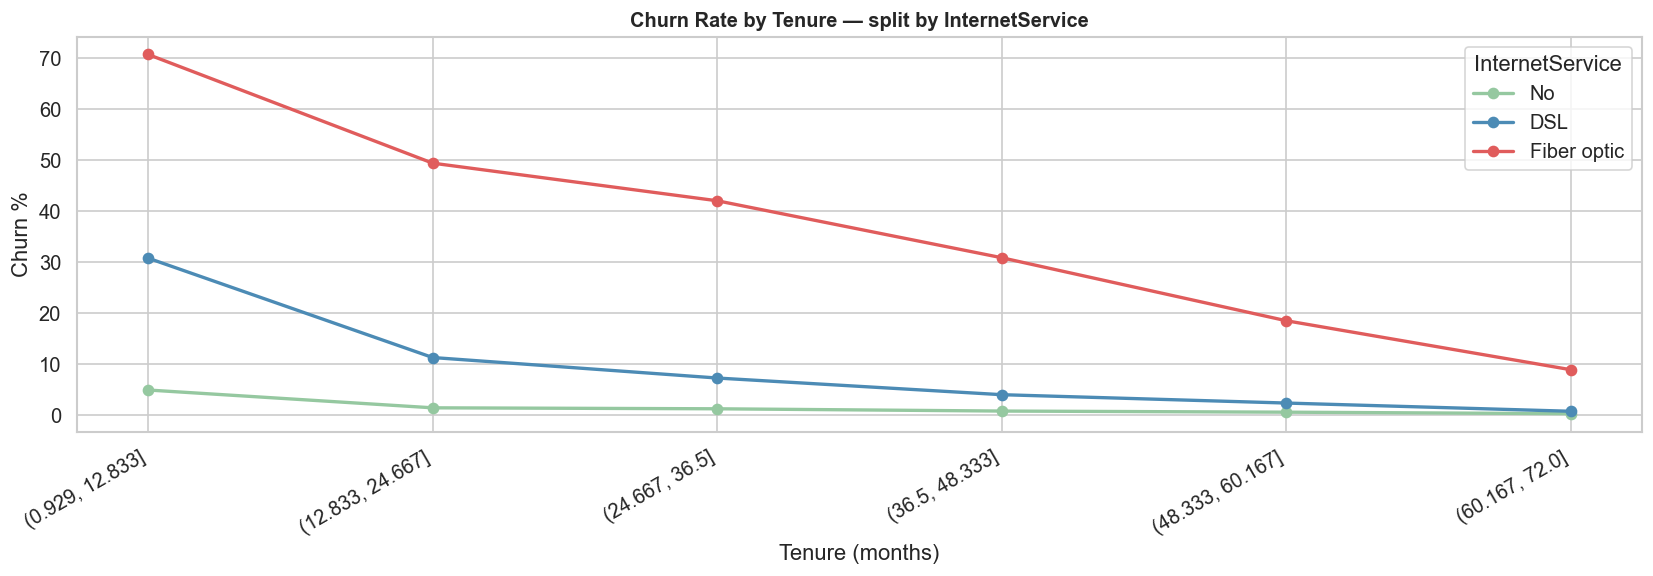

In [28]:
# ── Tenure × InternetService: churn rate across tenure bins ───────────────
train['tenure_bin'] = pd.cut(train['tenure'], bins=6)

fig, ax = plt.subplots(figsize=(14, 5))
for svc, color in zip(['No', 'DSL', 'Fiber optic'], ['#95C8A0', '#4C8BB5', '#E05C5C']):
    sub = train[train['InternetService'] == svc]
    curve = (
        sub.groupby('tenure_bin', observed=True)[TARGET]
        .apply(churn_rate)
    )
    ax.plot(
        range(len(curve)), curve.values,
        marker='o', label=svc, color=color, linewidth=2
    )

ax.set_xticks(range(len(curve)))
ax.set_xticklabels([str(b) for b in curve.index], rotation=30, ha='right')
ax.set_title('Churn Rate by Tenure — split by InternetService', fontsize=12, fontweight='bold')
ax.set_ylabel('Churn %')
ax.set_xlabel('Tenure (months)')
ax.legend(title='InternetService')
plt.tight_layout()
plt.show()

train.drop(columns='tenure_bin', inplace=True)

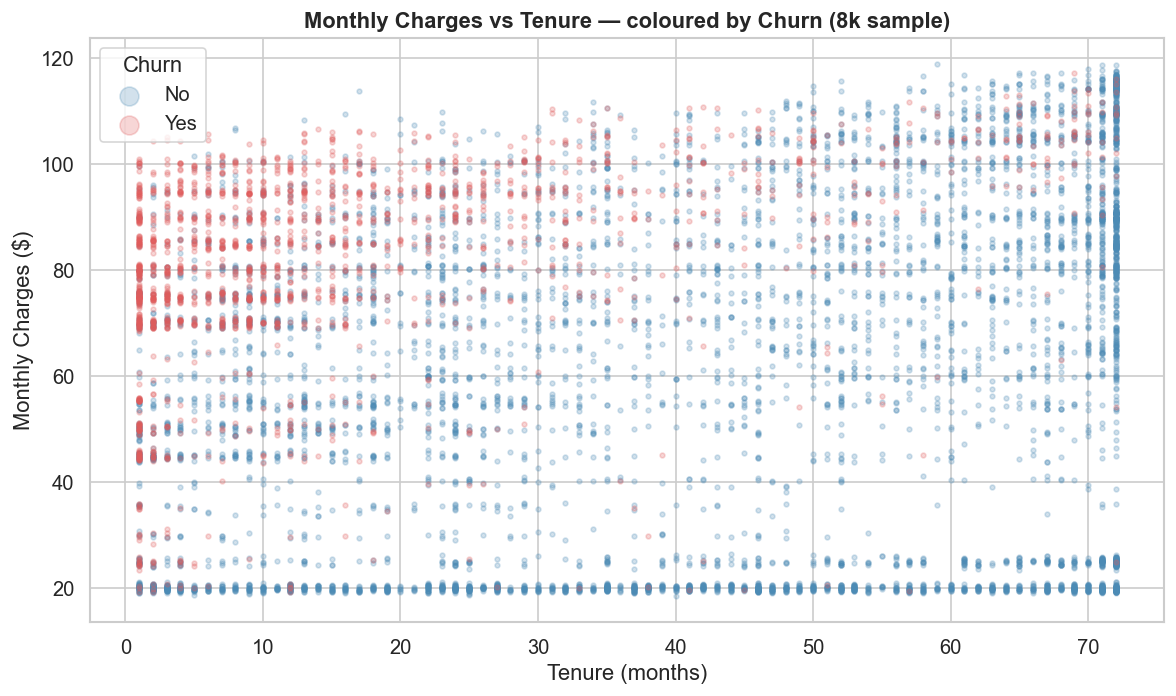

In [29]:
# ── MonthlyCharges × Tenure scatter (sample) ──────────────────────────────
sample = train.sample(n=8000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
for label, color in CHURN_PALETTE.items():
    sub = sample[sample[TARGET] == label]
    ax.scatter(
        sub['tenure'], sub['MonthlyCharges'],
        alpha=0.25, s=8, color=color, label=label
    )
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Monthly Charges ($)')
ax.set_title(
    'Monthly Charges vs Tenure — coloured by Churn (8k sample)',
    fontweight='bold'
)
ax.legend(title='Churn', markerscale=4)
plt.tight_layout()
plt.show()

---
## 13. Train vs Test Distribution Check

Since this is synthetic data, we verify that train and test come from the same distribution — no covariate shift to worry about.

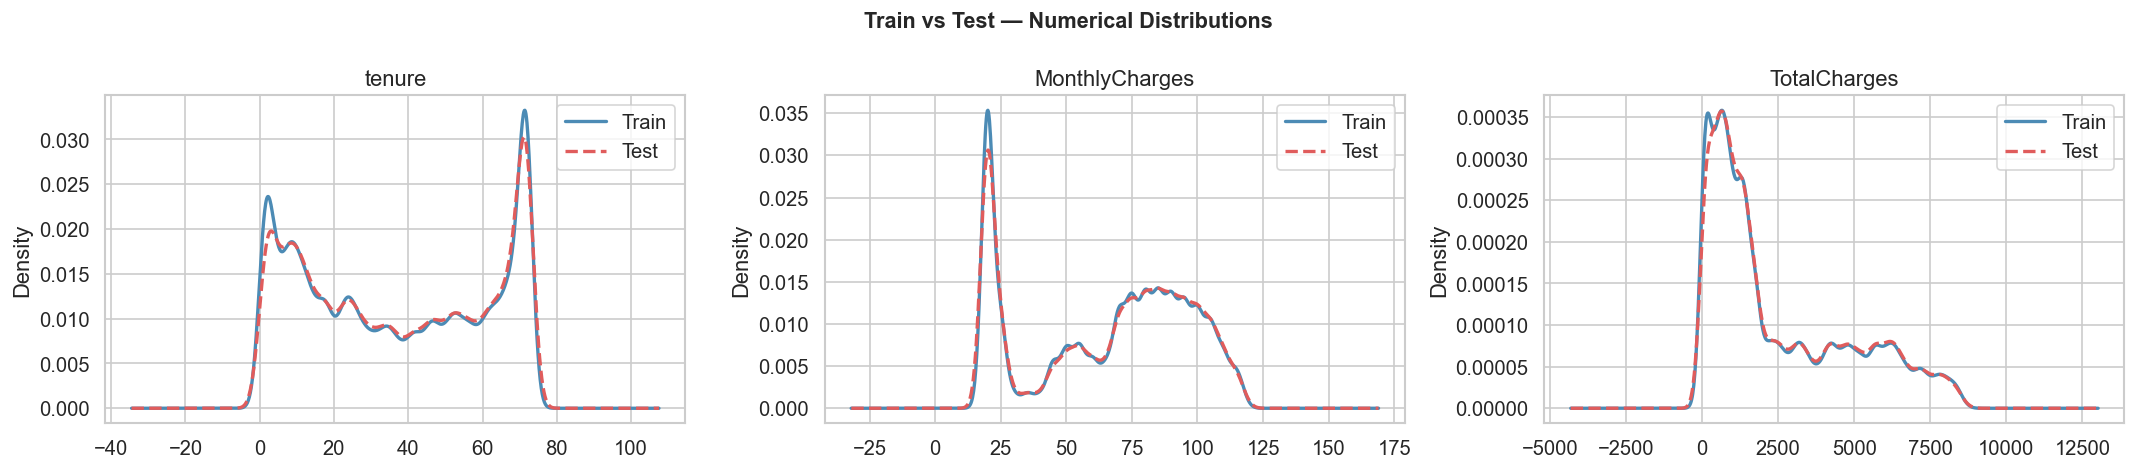

In [30]:
# ── Numerical: KDE overlay ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, NUMERICAL):
    train[col].plot.kde(ax=ax, label='Train', color='#4C8BB5', linewidth=2)
    test[col].plot.kde(ax=ax, label='Test',  color='#E05C5C', linewidth=2, linestyle='--')
    ax.set_title(col)
    ax.legend()
fig.suptitle('Train vs Test — Numerical Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# ── Statistical tests ─────────────────────────────────────────────────────
print("Distribution shift tests:\n")
print(f"{'Feature':<25} {'Test':<10} {'Statistic':>12} {'p-value':>12}  {'Status'}")
print('-' * 75)

for col in NUMERICAL:
    stat, p = ks_2samp(train[col], test[col])
    flag = '✅ OK' if p > 0.01 else '⚠️  SHIFT'
    print(f"{col:<25} {'KS':<10} {stat:>12.4f} {p:>12.4f}  {flag}")

all_cat_cols = BINARY_COLS + INTERNET_ADDON_COLS + ['MultipleLines','InternetService'] + ACCOUNT_COLS
for col in all_cat_cols:
    all_cats  = set(train[col].unique()) | set(test[col].unique())
    tr_counts = train[col].value_counts().reindex(all_cats, fill_value=0)
    te_counts = test[col].value_counts().reindex(all_cats, fill_value=0)
    chi2, p, _, _ = chi2_contingency(pd.DataFrame({'train': tr_counts, 'test': te_counts}).T)
    flag = '✅ OK' if p > 0.001 else '⚠️  SHIFT'
    print(f"{col:<25} {'Chi2':<10} {chi2:>12.1f} {p:>12.4f}  {flag}")

Distribution shift tests:

Feature                   Test          Statistic      p-value  Status
---------------------------------------------------------------------------
tenure                    KS               0.0171       0.0000  ⚠️  SHIFT
MonthlyCharges            KS               0.0065       0.0000  ⚠️  SHIFT
TotalCharges              KS               0.0177       0.0000  ⚠️  SHIFT
gender                    Chi2                0.1       0.7526  ✅ OK
SeniorCitizen             Chi2                0.4       0.5243  ✅ OK
Partner                   Chi2               45.7       0.0000  ⚠️  SHIFT
Dependents                Chi2                4.2       0.0408  ✅ OK
PhoneService              Chi2                0.3       0.6039  ✅ OK
PaperlessBilling          Chi2                0.0       0.8747  ✅ OK
OnlineSecurity            Chi2               29.1       0.0000  ⚠️  SHIFT
OnlineBackup              Chi2               45.9       0.0000  ⚠️  SHIFT
DeviceProtection          Chi2       

---
## 14. Encoding Decisions & Takeaways

In [32]:
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║                     EDA CONCLUSIONS & ENCODING PLAN                      ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  WHAT WE LEARNED                                                         ║
║  • InternetService is the dominant feature — Fiber optic has by far      ║
║    the highest churn; No internet customers are stable and loyal         ║
║  • Contract type is the second strongest signal — Month-to-month         ║
║    customers churn at 3-4x the rate of two-year customers                ║
║  • Tenure: churn is heavily concentrated in the first 12 months          ║
║  • TechSupport & OnlineSecurity: not having them = strong churn signal   ║
║  • gender: almost no signal — nearly equal churn rates                   ║
║  • PhoneService: weak signal — 90% of customers have it                  ║
║  • payment_type Automatic vs Manual: meaningful split especially with    ║
║    electronic check                                                      ║
║                                                                          ║
║  ENCODING PLAN                                                           ║
║  • Binary cols      → 0/1 (Yes=1, No=0)                                  ║
║  • InternetService  → keep 3-way, ordinal: No=0, DSL=1, Fiber=2          ║
║  • MultipleLines    → keep 3-way: No phone=0, No=1, Yes=2                ║
║  • Add-on cols      → keep 3-way: No internet=0, No=1, Yes=2             ║
║    (No internet service encodes the absence of internet itself)          ║
║  • Contract         → ordinal: Month-to-month=0, One year=1, Two year=2  ║
║  • payment_type     → binary: Manual=0, Automatic=1                      ║
║  • payment_method   → one-hot (4 categories, no natural order)           ║
║                                                                          ║
║  FEATURE ENGINEERING (informed by EDA)                                   ║
║  • has_internet     → binary flag (InternetService != 'No')              ║
║  • is_fiber         → binary flag (InternetService == 'Fiber optic')     ║
║  • num_addons       → count of add-on services = 'Yes'                   ║
║  • has_any_security → OnlineSecurity or TechSupport == 'Yes'             ║
║  • is_new_customer  → tenure <= 3                                        ║
║  • avg_monthly      → TotalCharges / (tenure + 1)                        ║
║  • charge_per_addon → MonthlyCharges / (num_addons + 1)                  ║
║  • contract × internet interaction                                       ║
╚══════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════╗
║                     EDA CONCLUSIONS & ENCODING PLAN                      ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  WHAT WE LEARNED                                                         ║
║  • InternetService is the dominant feature — Fiber optic has by far      ║
║    the highest churn; No internet customers are stable and loyal         ║
║  • Contract type is the second strongest signal — Month-to-month         ║
║    customers churn at 3-4x the rate of two-year customers                ║
║  • Tenure: churn is heavily concentrated in the first 12 months          ║
║  • TechSupport & OnlineSecurity: not having them = strong churn signal   ║
║  • gender: almost no signal — nearly equal churn rates                   ║
║  • PhoneService: weak signal — 90% of customers have it                  